# COMP3010 - Machine Learning
# Machine Learning Assignment 

- Author: Emmanuel Buruvuru
- Kaggle name: Sycolee
- Date: 14/04/2024
- File: Buruvuru_Emmanuel_Machine_Learning_Assignment.ipynb 
- Description: This is the notebook for the machine learning assignment.    

# Disscussion of the problem 

The problem is to predict the pressure at which a tank will fail. The assignment will use a dataset that will be provided to train a machine learning model to predict the tank failure pressure. The dataset contains columns that will be used as features to predict the target variable, which is the tank failure pressure. The dataset will be preprocessed, and the features will be used to train the machine learning model. The model will be evaluated using appropriate metrics such as accuracy, precision, recall, F1 score, and ROC-AUC. The model will be optimized using hyperparameter tuning techniques such as Grid Search, Random Search, or Bayesian Optimization. The final model will be tested on the testing data to assess its performance on unseen data. The model will be used to make predictions on new data instances, and the final performance metrics of the model will be reported. The model will be deployed to a production environment for real-time predictions. The models will be evaluated using metrics such as MAPE (Mean Absolute Percentage Error) and R2, both available in the Scikit-learn library. Additional metrics such as RMSE (Root Mean Square Error) or MAE (Mean Absolute Error) will be considered to gain a more comprehensive understanding of the models' performance. The assignment will also explore other model development techniques to improve the model's performance.

# Outline of the notebook

- [Task one: Data Preprocessing](#1)
    - [Load the data](#2)
    - [Handle missing values](#3)
    - [Detect and remove outliers](#4)
    - [Check for duplicates](#5)
    - [Select features with correlation](#6)
    - [Feature engineering](#7)
    - [Data type conversion](#8)
    - [Feature scaling](#9)
    - [Data Augmentation](#10)
    - [Data Encoding for categorical columns](#11)
    - [Data Preprocessing](#12)
    - [Split the data](#13)

- [Task two: Model Development](#14)
    - [Visualize the data](#15)
    - [Train and evaluate the models](#16)
    - [Hyperparameter tuning](#18)
    - [Model Prediction](#17) 
    - [Model graphs](#19)
    - [Model Ensembling of Svr and Random Forest](#20)
        

In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler


ModuleNotFoundError: No module named 'pandas'

<a name="1"></a>

## Load the data 

The first step in the data preprocessing process is to load the data. The data will be loaded from a CSV file using the `pd.read_csv()` function from the pandas library. The data will be stored in a pandas DataFrame for further processing.



In [ ]:
# Load the data

def load_data(file_path):
    return pd.read_csv(file_path)

<a name="2"></a>

## Handle missing values

The next step in the data preprocessing process is to handle missing values. Missing values can affect the performance of the machine learning model, so it is important to identify and handle them appropriately. The `handle_missing_values()` function will be used to identify and handle missing values in the dataset. The function will use the `SimpleImputer` class from the scikit-learn library to impute missing values for numeric and categorical columns. The `strategy` parameter will be used to specify the imputation strategy, which can be 'mean', 'median', 'most_frequent', or 'constant'. The default strategy is 'mean' for numeric columns and 'most_frequent' for categorical columns. The function will print the number of missing values in the dataset before and after imputation.


In [ ]:

# Identify and handle missing values
def handle_missing_values(data_processing, numeric_strategy='mean', categorical_strategy='most_frequent'):
    
    # Print number of missing values in the data set 
    # print('Number of missing values in the data set: ', data_processing.isnull().sum().sum())
    
    #Drop unnecessary columns
    data_processing = data_processing.drop(['ID'], axis=1)
    
    # Identify missing values
    numeric_cols = data_processing.select_dtypes(include='number').columns
    categorical_cols = data_processing.select_dtypes(exclude='number').columns

    # Impute missing values for numeric columns
    if not numeric_cols.empty:
        numeric_impute = SimpleImputer(strategy=numeric_strategy)
        data_processing[numeric_cols] = numeric_impute.fit_transform(data_processing[numeric_cols])

    # Impute missing values for categorical columns
    if not categorical_cols.empty:
        categorical_impute = SimpleImputer(strategy=categorical_strategy)
        data_processing[categorical_cols] = categorical_impute.fit_transform(data_processing[categorical_cols])

    # Print number of missing values in the data set after imputation
    # print('Number of missing values in the data set after imputation: ', data_processing.isnull().sum().sum())

    return data_processing


<a name="3"></a>

## Detect and remove outliers

The next step in the data preprocessing process is to detect and remove outliers. Outliers can affect the performance of the machine learning model, so it is important to identify and remove them appropriately. The `detect_outliers()` function will be used to detect and remove outliers in the dataset. The function will use the Interquartile Range (IQR) method to identify outliers for numeric columns. The function will calculate the lower and upper bounds for each numeric column and remove rows that fall outside these bounds. The function will print the number of outliers in the dataset before and after removal.


In [ ]:
# Detect and remove outliers

def detect_outliers(data_processing):
    # Copy the original DataFrame to avoid modifying the original data
    processed_data = data_processing.copy()
    
    # Identify outliers for numeric columns
    numeric_cols = processed_data.select_dtypes(include='number').columns

    # Remove outliers for numeric columns
    for col in numeric_cols:
        q1 = processed_data[col].quantile(0.25)
        q3 = processed_data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        processed_data = processed_data[(processed_data[col] >= lower_bound) & (processed_data[col] <= upper_bound)]
        

    # Identify outliers for categorical columns
    categorical_cols = processed_data.select_dtypes(exclude='number').columns  
    
    # Remove outlier if the numeric column has more than four decimal places
    for col in numeric_cols:
        processed_data[col] = processed_data[col].apply(lambda x: round(x, 4))
        

    # Remove outliers for categorical columns
    # print("\nNumber of outliers in the data set after removal (categorical columns):")
    for col in categorical_cols:
        num_outliers = processed_data[col].nunique() - processed_data[col].value_counts().max()
        processed_data = processed_data[processed_data[col].map(processed_data[col].value_counts()) > 1] 

    # Print number of outliers in the data set after removal
    # print('Total number of rows after outlier removal: ', processed_data.shape[0])

    # Return the processed data
    return processed_data




<a name="4"></a>

## Check for duplicates

The next step in the data preprocessing process is to check for duplicates. Duplicates can affect the performance of the machine learning model, so it is important to identify and remove them appropriately. The `check_duplicates()` function will be used to check for duplicates in the dataset. The function will print the number of duplicates in the dataset and remove them if any duplicates are found. The function will print the number of duplicates in the dataset after removal.

In [ ]:
# Checking for duplicates
def check_duplicates(data_processing):
    # Check for duplicates
    num_duplicates = data_processing.duplicated().sum()
    

    # Remove duplicates
    processed_data = data_processing.drop_duplicates()

    # Print number of duplicates in the data set after removal
    num_duplicates = processed_data.duplicated().sum()
    

    return processed_data

<a name="5"></a>

## Select features with correlation

The next step in the data preprocessing process is to select features based on their correlation with the target variable. The `select_features_with_correlation()` function will be used to select features from the dataset based on their correlation with the target variable. The function will compute the correlation matrix and select features with a correlation coefficient greater than the specified threshold. The function will print the selected features based on correlation.


In [ ]:

def determine_correlation_threshold(data, target_column):
 

    # Compute correlation coefficients between features and the target variable
    correlations = data.corr()[target_column].abs()

    # Calculate mean absolute correlation coefficient
    mean_corr = correlations.mean()

    # Define the correlation threshold as a multiple of the mean absolute correlation
    correlation_threshold = mean_corr * 0.03  # Adjust the multiplier as needed

    return correlation_threshold


def select_features_with_correlation(data, correlation_threshold):

    # Compute correlation matrix
    correlation_matrix = data.corr()

    # Select features with correlation to the target variable
    target_column = correlation_matrix.columns[-1]  # Assuming the last column is the target variable
    relevant_features = correlation_matrix[abs(correlation_matrix[target_column]) > correlation_threshold].index.tolist()

    # Filter features
    selected_features = data[relevant_features] 

    return selected_features


<a name="6"></a>

## Feature engineering

The next step in the data preprocessing process is to perform feature engineering. Feature engineering involves creating new features from the existing features in the dataset. The `feature_engineering()` function will be used to create new features based on the existing features in the dataset. The function will create new features such as volume, volume to surface area ratio, width to length ratio, width to height ratio, and length to height ratio. The function will reorder the columns in the dataset to put the new features in the second position.


In [ ]:
# Feature engineering of volume
def feature_engineering(data_processing):
    # Create a new feature by calculating the volume of the tank and put the column in the second position
    data_processing['Volume'] = data_processing['Tank Width (m)'] * data_processing['Tank Length (m)'] * data_processing['Tank Height (m)'] 
    
    # Calculate tank volume to surface area ratio
    data_processing['Volume_to_Surface_Area'] = data_processing['Volume'] / (2 * (data_processing['Tank Width (m)'] * data_processing['Tank Length (m)'] + data_processing['Tank Width (m)'] * data_processing['Tank Height (m)'] + data_processing['Tank Length (m)'] * data_processing['Tank Height (m)'])) 
    
    # Calculate the ratio of the tank width to the tank length
    data_processing['Width_to_Length_Ratio'] = data_processing['Tank Width (m)'] / data_processing['Tank Length (m)']
     
     # presure difference
    data_processing.loc[:, 'Pressure Difference'] = data_processing['Tank Failure Pressure (bar)'] - data_processing['Liquid Critical Pressure (bar)']
    
    # Calculate the ratio of the tank width to the tank height
    data_processing['Width_to_Height_Ratio'] = data_processing['Tank Width (m)'] / data_processing['Tank Height (m)']
    
    # Calculate the ratio of the tank length to the tank height
    data_processing['Length_to_Height_Ratio'] = data_processing['Tank Length (m)'] / data_processing['Tank Height (m)']

    
    # Reorder all the columns to be first in the dataset 
    data_processing = data_processing[['Volume'] + [col for col in data_processing.columns if col != 'Volume']] 
    data_processing = data_processing[['Volume_to_Surface_Area'] + [col for col in data_processing.columns if col != 'Volume_to_Surface_Area']] 
    data_processing = data_processing[['Width_to_Length_Ratio'] + [col for col in data_processing.columns if col != 'Width_to_Length_Ratio']]
    data_processing = data_processing[['Width_to_Height_Ratio'] + [col for col in data_processing.columns if col != 'Width_to_Height_Ratio']]
    data_processing = data_processing[['Length_to_Height_Ratio'] + [col for col in data_processing.columns if col != 'Length_to_Height_Ratio']]
    data_processing = data_processing[['Pressure Difference'] + [col for col in data_processing.columns if col != 'Pressure Difference']]
    
    
    
    
    return data_processing

<a name="7"></a>

## Data type conversion

The next step in the data preprocessing process is to convert the data types of the columns in the dataset. The `data_type_conversion()` function will be used to convert the data types of the columns in the dataset to the appropriate data types. The function will convert the 'Tank Width (m)', 'Tank Length (m)', 'Tank Height (m)', 'Volume', and 'Volume_to_Surface_Area' columns to float data type.


In [ ]:
# Data type conversion
def data_type_conversion(data_processing):
    
    # Convert the 'Tank Width (m)', 'Tank Length (m)', 'Tank Height (m)', 'Volume', and 'Volume_to_Surface_Area' columns to float
    data_processing[['Tank Width (m)', 'Tank Length (m)', 'Tank Height (m)', 'Volume', 'Volume_to_Surface_Area']] = data_processing[['Tank Width (m)', 'Tank Length (m)', 'Tank Height (m)', 'Volume', 'Volume_to_Surface_Area']].astype(float)
    
    # 
    
    return data_processing


<a name="8"></a>

## Feature scaling

The next step in the data preprocessing process is to scale the features in the dataset. Feature scaling is important to ensure that all features have the same scale, which can improve the performance of the machine learning model. The `feature_scaling()` function will be used to scale the features in the dataset using the normalization technique. The function will use the `MinMaxScaler` class from the scikit-learn library to scale the features in the dataset.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

def feature_scaling(data_processing):
    # Copy the original DataFrame to avoid modifying the original data
    processed_data = data_processing.copy()
    
    # Separate the target variable from the features
    target_variable = processed_data['Target Pressure (bar)']
    features = processed_data.drop(columns=['Target Pressure (bar)'])
    
    # Initialize the MinMaxScaler
    scaler = MinMaxScaler()
    
    # Scale the features using normalization
    scaled_features = scaler.fit_transform(features)
    
    # Concatenate the scaled features with the target variable into a DataFrame
    processed_data = pd.DataFrame(scaled_features, columns=features.columns)
    processed_data['Target Pressure (bar)'] = target_variable
    
    return processed_data


<a name="9"></a>

## Data Augmentation

The next step in the data preprocessing process is data augmentation. Data augmentation is the process of increasing the amount of data by adding noise to the existing data. The `data_augmentation()` function will be used to add noise to the data in the dataset. The function will add noise to the data using a normal distribution with a mean of 0 and a standard deviation of 0.1.


In [ ]:
# Data Augmentation
def data_augmentation(data_processing):
    # Copy the original DataFrame to avoid modifying the original data
    processed_data = data_processing.copy()
    
    # Increase data instances using augmentation techniques
    # Add noise to the data
    noise = np.random.normal(0, 0.1, processed_data.shape)
    processed_data += noise

    return processed_data

<a name="10"></a>

## Data Encoding for categorical columns

The next step in the data preprocessing process is data encoding for categorical columns. Categorical columns need to be encoded into numerical values before they can be used in the machine learning model. The `data_encoding()` function will be used to encode the categorical columns in the dataset. The function will use one-hot encoding to encode the categorical columns in the dataset.


In [ ]:
# Data Encoding for categorical columns
def data_encoding(data_processing):
    # Copy the original DataFrame to avoid modifying the original data
    processed_data = data_processing.copy()
    
    # Identify categorical columns
    categorical_cols = processed_data.select_dtypes(exclude='number').columns
    
    # Perform one-hot encoding for categorical columns
    encoded_cols = pd.get_dummies(processed_data[categorical_cols], drop_first=True)
    
    # Drop original categorical columns
    processed_data.drop(columns=categorical_cols, inplace=True)
    
    # Concatenate encoded columns to the front of the DataFrame
    processed_data = pd.concat([encoded_cols, processed_data], axis=1)
    
    return processed_data


<a name="11"></a>

## Handling Imbalanced Data

The next step in the data preprocessing process is to handle imbalanced data. Imbalanced data can affect the performance of the machine learning model, so it is important to handle it appropriately. The `handle_imbalanced_data()` function will be used to handle imbalanced data in the dataset. The function will use techniques such as oversampling, undersampling, or SMOTE to balance the data. The function will return the balanced data.

In [ ]:
def handle_imbalanced_data(data_processing):
    """
    Regression-safe placeholder.

    SMOTE is designed for classification labels and is not appropriate for a
    continuous regression target like `Target Pressure (bar)`.
    We therefore return the input data unchanged.
    """
    return data_processing.copy()


<a name="11"></a>

## Data Preprocessing

The `data_preprocessing()` function will be used to perform all the data preprocessing steps on the dataset. The function will load the data, handle missing values, detect and remove outliers, check for duplicates, select features with correlation, perform feature engineering, convert the data types, scale the features, augment the data, and encode the categorical columns. The function will return the processed data.


In [ ]:
def data_preprocessing(train_file_path):
    # Load the training data
    train_data = load_data(train_file_path)
    
    # Handle missing values for training data
    train_data = handle_missing_values(train_data)
    
    # Detect and remove outliers for training data
    train_data = detect_outliers(train_data)
    
    # Check for duplicates for training data
    train_data = check_duplicates(train_data)
    
    # Data encoding for training data
    train_data = data_encoding(train_data)
    
    # Feature engineering for training data
    train_data = feature_engineering(train_data)
    
    # Data type conversion for training data
    train_data = data_type_conversion(train_data)
    
    # Feature selection for training data
    correlation_threashold = determine_correlation_threshold(train_data, 'Tank Failure Pressure (bar)')
    print(f"Correlation threshold: {correlation_threashold}")
    train_data = select_features_with_correlation(train_data, correlation_threashold)
    
    # Feature scaling for training data
    # train_data = feature_scaling(train_data)
    
    # Write the processed training data to a new CSV file    
    train_data.to_csv('train_processed.csv', index=False)
    
    return train_data


<a name="12"></a>
## Split the data

The next step in the data preprocessing process is to split the data into training and testing sets. The `split_data()` function will be used to split the data into training and testing sets. The function will separate the features and target for the training and testing data. The function will return the features and target for the training and testing data.



In [ ]:
def split_data(train_data, test_size=0.2, random_state=42):
    from sklearn.model_selection import train_test_split

    # Separate features and target
    X = train_data.iloc[:, :-1]
    y = train_data.iloc[:, -1]

    # Proper train/test split to avoid data leakage
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    return X_train, y_train, X_test, y_test


In [ ]:
# Load the data
train_file_path = 'train.csv'

train_data = data_preprocessing(train_file_path)

# Split the data into training and testing sets
X_train, y_train, X_test, y_test = split_data(train_data)


Correlation threshold: 0.004479587943147519


<a name="14"></a>

## Model Development

The next step in the machine learning process is to develop a model to predict the tank failure pressure. In this section, you will implement a linear regression model using the scikit-learn library. You will train the model on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score. You will also implement a support vector regression (SVR) model using the scikit-learn library. You will train the model on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score. You will implement a random forest regression model using the scikit-learn library. You will train the model on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score. You will implement an XGBoost regression model using the XGBoost library. You will train the model on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score.



## Visualize the data 

The next step in the data preprocessing process is to visualize the data. The `visualize_data()` function will be used to visualize the data that has been processed. The function will plot the distribution of the target variable and the correlation matrix of the features in the dataset.


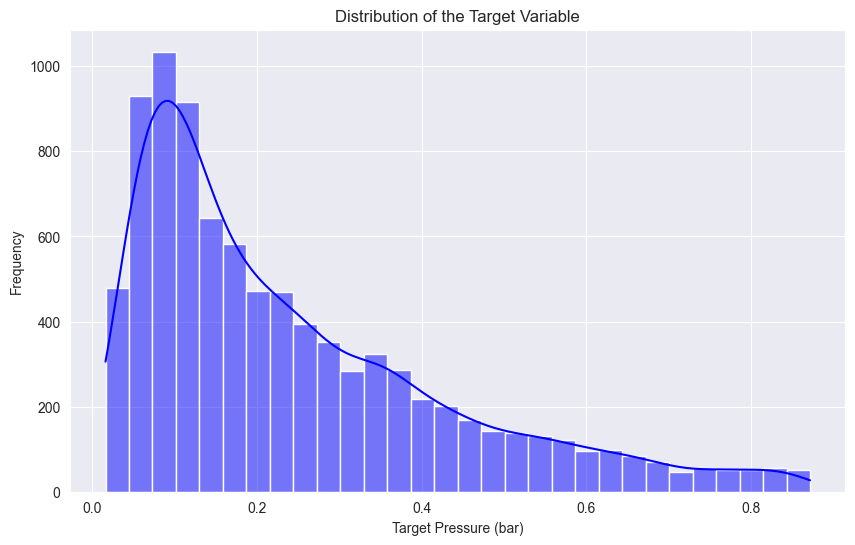

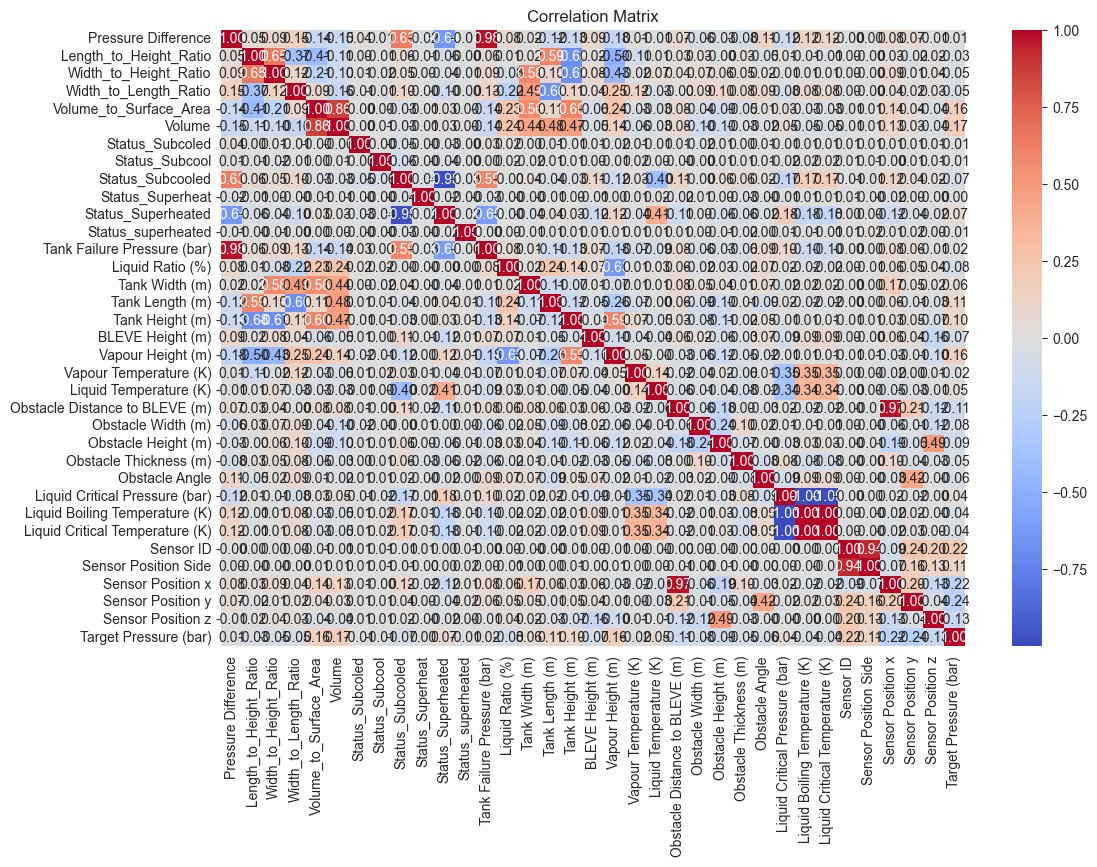

In [ ]:
# Visualise the data that has been processed 

# Plot the distribution of the target variable

plt.figure(figsize=(10, 6))
sns.histplot(y_train, kde=True, color='b', bins=30)
plt.title('Distribution of the Target Variable')
plt.xlabel('Target Pressure (bar)')
plt.ylabel('Frequency')
plt.show()


# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()




<a name="15"></a>

## 4 Model Development

### Linear Regression Model
In this section, you will implement a linear regression model using the scikit-learn library. You will train the model on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score.

### SVR Model
You will also implement a support vector regression (SVR) model using the scikit-learn library. You will train the model on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score.

### Random Forest Model
You will implement a random forest regression model using the scikit-learn library. You will train the model on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score.

### XGBoost Model
You will implement an XGBoost regression model using the XGBoost library. You will train the model on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score.
   

In [ ]:
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.linear_model import Ridge

def train_evaluate_models(x_train, y_train, x_test, y_test):
    # Initialize three different types of models
    linear_model = Ridge()  # Adding L2 regularization (Ridge) to Linear Regression
    svr_model = SVR()
    random_forest_model = RandomForestRegressor()
    xgboost_model = XGBRegressor()
    
    # Train the models
    linear_model.fit(x_train, y_train)
    svr_model.fit(x_train, y_train)
    random_forest_model.fit(x_train, y_train)
    xgboost_model.fit(x_train, y_train)
    
    # Evaluate the models
    linear_mape = mean_absolute_percentage_error(y_test, linear_model.predict(x_test))
    svr_mape = mean_absolute_percentage_error(y_test, svr_model.predict(x_test))
    random_forest_mape = mean_absolute_percentage_error(y_test, random_forest_model.predict(x_test))
    xgboost_mape = mean_absolute_percentage_error(y_test, xgboost_model.predict(x_test))
    
    linear_r2 = r2_score(y_test, linear_model.predict(x_test))
    svr_r2 = r2_score(y_test, svr_model.predict(x_test))
    random_forest_r2 = r2_score(y_test, random_forest_model.predict(x_test))
    xgboost_r2 = r2_score(y_test, xgboost_model.predict(x_test))
    
    print("Linear Regression:")
    print(f"MAPE: {linear_mape}, R2: {linear_r2}")
    print("\nSVR:")
    print(f"MAPE: {svr_mape}, R2: {svr_r2}")
    print("\nRandom Forest:")
    print(f"MAPE: {random_forest_mape}, R2: {random_forest_r2}")
    print("\nXGBoost:")
    print(f"MAPE: {xgboost_mape}, R2: {xgboost_r2}") 
    
    return linear_model, svr_model, random_forest_model, xgboost_model


<a name="16"></a>

## Model Prediction

The next step in the machine learning process is to make predictions using the trained models. The `model_prediction()` function will be used to make predictions using the trained models on the testing data. The function will write the predictions to a CSV file with the ID and the predicted target pressure.


In [ ]:
# Model prediction of the models writing to a csv file with ID and the Target pressure
def model_prediction(model, X, file_path):
    # Make predictions on the data instances
    predictions = model.predict(X)
    
    # Create a DataFrame with the ID and the predictions
    df = pd.DataFrame({'ID': range(len(predictions)), 'Target Pressure (bar)': predictions})
    
    # Only write 3000 rows to the CSV file
    df.head(3203).to_csv(file_path, index=False)  
    
    return df

<a name="18"></a>

## Model graphs

The next step in the machine learning process is to visualize the models' performance. The `model_graphs()` function will be used to plot the performance of the models. The function will plot the linearity of the linear regression model, the support vectors of the SVR model, the estimators of the random forest model, and the loss of the neural network model. The function will also plot the residuals of the models.



In [ ]:
def model_graphs(model, X_test, y_test):
    # Plot the lineear regression model
    if hasattr(model, 'coef_'):
        plt.figure(figsize=(10, 6))
        plt.scatter(model.predict(X_test), y_test, c='b', s=40, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Linear Regression Model')
        plt.show()
        
    # Plot the support vector regression model
    if hasattr(model, 'support_vectors_'):
        plt.figure(figsize=(10, 6))
        plt.scatter(model.predict(X_test), y_test, c='b', s=40, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Support Vector Regression Model')
        plt.show()
        
    # Plot the random forest model
    if hasattr(model, 'estimators_'):
        plt.figure(figsize=(10, 6))
        plt.scatter(model.predict(X_test), y_test, c='b', s=40, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Random Forest Model')
        plt.show()


<a name="19"></a>

## Train and evaluate the models

The next step in the machine learning process is to train and evaluate the models. The `train_evaluate_models()` function will be used to train and evaluate the models on the training and testing data. The function will return the trained models and their performance metrics.



In [2]:
# Train and evaluate the models

linear_model, svr_model, random_forest_model, xgboost_model = train_evaluate_models(X_train, y_train, X_test, y_test) 


# Model prediction
linear_predictions = model_prediction(linear_model, X_test, 'linear_predictions.csv')
svr_predictions = model_prediction(svr_model, X_test, 'svr_predictions.csv')
random_forest_predictions = model_prediction(random_forest_model, X_test, 'random_forest_predictions.csv')
xgboost_predictions = model_prediction(xgboost_model, X_test, 'xgboost_predictions.csv')

# Model graphs
model_graphs(linear_model, X_test, y_test)
model_graphs(svr_model, X_test, y_test)
model_graphs(random_forest_model, X_test, y_test)
model_graphs(xgboost_model, X_test, y_test)


NameError: name 'train_evaluate_models' is not defined

<a name="20"></a>

## Model Ensembling of Svr and Random Forest

The next step in the machine learning process is to ensemble the models. The `model_ensembling()` function will be used to ensemble the SVR and Random Forest models. The function will create a voting regressor using the SVR and Random Forest models. The function will train the voting regressor on the training data and evaluate its performance using the mean absolute percentage error (MAPE) and R2 score.


In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import GridSearchCV

# Define hyperparameters grid for SVR
svr_params = {'C': [0.1, 1.0, 10.0], 'epsilon': [0.1, 0.01, 0.001]}

# Define hyperparameters grid for Random Forest
random_forest_params = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20]}

# Perform hyperparameter tuning using GridSearchCV for SVR
svr_model = GridSearchCV(SVR(), svr_params, scoring='neg_mean_absolute_percentage_error', cv=3)

# Perform hyperparameter tuning using GridSearchCV for Random Forest
random_forest_model = GridSearchCV(RandomForestRegressor(), random_forest_params, scoring='neg_mean_absolute_percentage_error', cv=3)

# Create a voting regressor
voting_regressor = VotingRegressor(estimators=[('svr', svr_model), ('random_forest', random_forest_model)])

# Train the model
voting_regressor.fit(X_train, y_train)

# Evaluate the model
voting_mape = mean_absolute_percentage_error(y_test, voting_regressor.predict(X_test))
voting_r2 = r2_score(y_test, voting_regressor.predict(X_test))

print(f"Voting Regressor MAPE: {voting_mape}, R2: {voting_r2}")

# Model prediction
voting_predictions = model_prediction(voting_regressor, X_test, 'prediction.csv')

# Model graphs
model_graphs(voting_regressor, X_test, y_test)


#